In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_3sec = pd.read_csv("data/features_3_sec.csv")
df_30sec = pd.read_csv("data/features_30_sec.csv")

In [3]:
df_3sec.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [4]:
df_3sec.dtypes

filename                    object
length                       int64
chroma_stft_mean           float64
chroma_stft_var            float64
rms_mean                   float64
rms_var                    float64
spectral_centroid_mean     float64
spectral_centroid_var      float64
spectral_bandwidth_mean    float64
spectral_bandwidth_var     float64
rolloff_mean               float64
rolloff_var                float64
zero_crossing_rate_mean    float64
zero_crossing_rate_var     float64
harmony_mean               float64
harmony_var                float64
perceptr_mean              float64
perceptr_var               float64
tempo                      float64
mfcc1_mean                 float64
mfcc1_var                  float64
mfcc2_mean                 float64
mfcc2_var                  float64
mfcc3_mean                 float64
mfcc3_var                  float64
mfcc4_mean                 float64
mfcc4_var                  float64
mfcc5_mean                 float64
mfcc5_var           

In [5]:
# df_3sec.isna().sum(), df_30sec.isna().sum() 

In [6]:
# data cleaning
# df_30sec.columns = df_3sec.columns.str.lower().str.replace(' ', '_')

numerical_columns = list(df_30sec.dtypes[df_30sec.dtypes.astype(str).isin(['float64', 'int64'])].index)
categorical_columns = list(df_30sec.dtypes[~df_30sec.dtypes.astype(str).isin(['float64', 'int64'])].index)

for col in numerical_columns:
    df_30sec[col] = df_30sec[col].fillna(df_30sec[col].median())

In [7]:
# split data and label encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# remove filename
del df_30sec['filename']

label_encoder = LabelEncoder()
df_30sec['label'] = label_encoder.fit_transform(df_30sec['label'])

df_full_train, df_test = train_test_split(df_30sec, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.label.values
y_val = df_val.label.values
y_test = df_test.label.values

del df_full_train['label']
del df_train['label']
del df_val['label']
del df_test['label']

# Logistic Regression

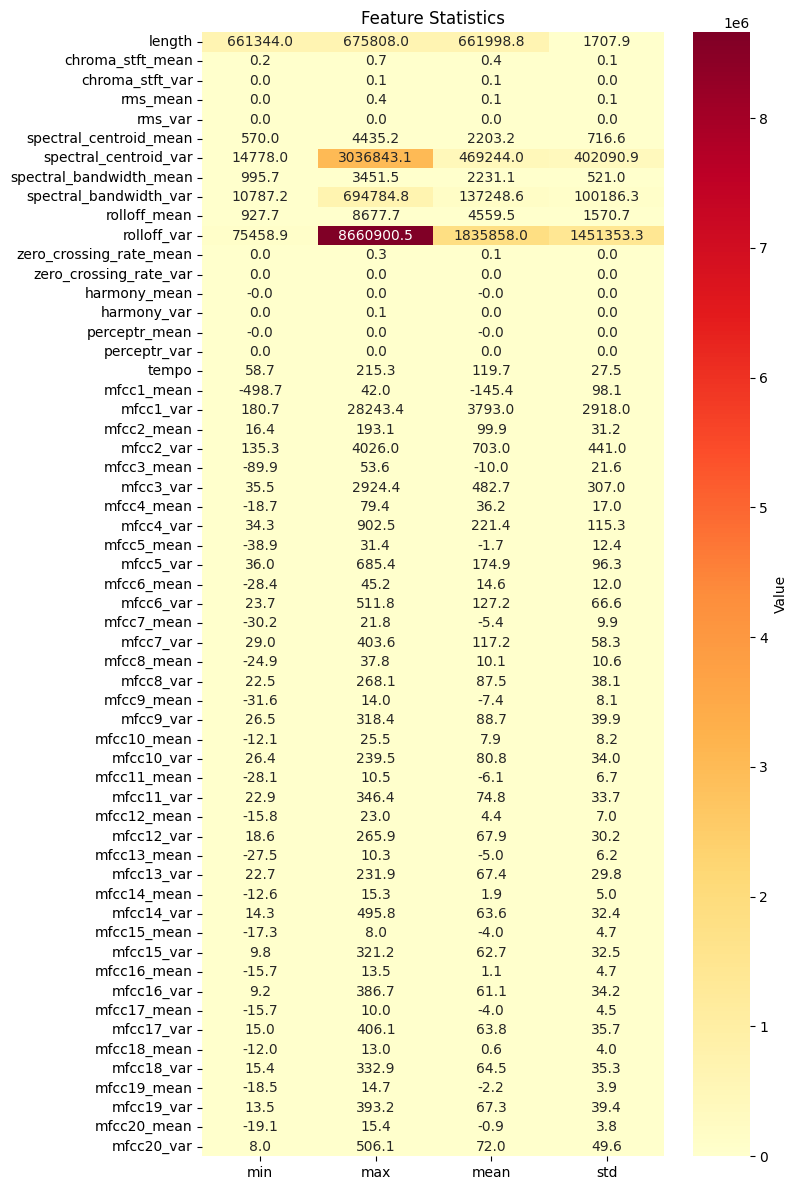

In [30]:
# check Scale
stats = df_train.describe().T[['min', 'max', 'mean', 'std']]

plt.figure(figsize=(8, 12))
sns.heatmap(stats, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Value'})
plt.title('Feature Statistics')
plt.tight_layout()
plt.show()

In [11]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_train_scaled = scaler.fit_transform(df_train)
df_val_scaled = scaler.transform(df_val)

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(df_train_scaled, y_train)

y_pred_proba = logistic_model.predict_proba(df_val_scaled)
y_pred = y_pred_proba.argmax(axis=1)
confidence = y_pred_proba.max(axis=1)

log_df_pred = pd.DataFrame()
log_df_pred['prediction'] = y_pred
log_df_pred['confidence'] = confidence
log_df_pred['actual'] = y_val
log_df_pred['correct'] = (log_df_pred['prediction'] == log_df_pred['actual'])

log_df_pred['correct'].mean()

np.float64(0.715)

In [51]:
# Using Logistic Regression Model
df_all_train = pd.concat([df_train, df_val], ignore_index=True)
y_full = np.concatenate([y_train, y_val])

scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(df_all_train)
df_test_scaled = scaler.transform(df_test)

y_full = np.concatenate([y_train, y_val])

logistic_model = LogisticRegression(max_iter=1000, solver='lbfgs')
logistic_model.fit(X_full_scaled, y_full)

y_pred_proba = logistic_model.predict_proba(df_test_scaled)
y_pred = y_pred_proba.argmax(axis=1)
confidence = y_pred_proba.max(axis=1)

log_df_pred = pd.DataFrame()
log_df_pred['prediction'] = y_pred
log_df_pred['confidence'] = confidence
log_df_pred['actual'] = y_test
log_df_pred['correct'] = (log_df_pred['prediction'] == log_df_pred['actual'])
log_df_pred['correct'].mean()

np.float64(0.7)

In [57]:
# Improve Logistic Regression Model with Hyperparameter tuning
from sklearn.metrics import f1_score

solvers = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
Cs = [0.001, 0.01, 0.1, 1.0, 10, 100]

df_all_train = pd.concat([df_train, df_val], ignore_index=True)
y_full = np.concatenate([y_train, y_val])

scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(df_all_train)
df_test_scaled = scaler.transform(df_test)

y_full = np.concatenate([y_train, y_val])

scores = []
for solver in solvers:
    for C in Cs:
        logistic_model = LogisticRegression(max_iter=1000, solver=solver, C=C)

        logistic_model.fit(X_full_scaled, y_full)
        y_pred_proba = logistic_model.predict_proba(df_test_scaled)
        y_pred = y_pred_proba.argmax(axis=1)
        confidence = y_pred_proba.max(axis=1)
        f1_score_macro = f1_score(y_test, y_pred, average='macro')
        scores.append({'solver': solver, 'C': C, 'f1_score': f1_score_macro})

/Users/prograsshopper/Library/Caches/pypoetry/virtualenvs/music-genre-classification-j2uQ-VrF-py3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/Users/prograsshopper/Library/Caches/pypoetry/virtualenvs/music-genre-classification-j2uQ-VrF-py3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/Users/prograsshopper/Library/Caches/pypoetry/virtualenvs/music-genre-classifica

In [59]:
sorted(scores, key=lambda x: x['f1_score'])[-1]

{'solver': 'saga', 'C': 0.1, 'f1_score': 0.7047647751285522}

# Decision Tree

In [50]:

from sklearn.tree import DecisionTreeClassifier, export_text

decision_tree = DecisionTreeClassifier(max_depth=10, random_state=1)
decision_tree.fit(df_train, y_train)

y_pred_proba = decision_tree.predict_proba(df_val)
y_pred = y_pred_proba.argmax(axis=1)
confidence = y_pred_proba.max(axis=1)

dt_df_pred = pd.DataFrame()
dt_df_pred['prediction'] = y_pred
dt_df_pred['confidence'] = confidence
dt_df_pred['actual'] = y_val
dt_df_pred['correct'] = (dt_df_pred['prediction'] == dt_df_pred['actual'])

dt_df_pred['correct'].mean()

np.float64(0.595)

In [65]:
dt_scores = []

for depth in range(5, 20):
    for s in [1, 5, 10, 15, 20, 50, 100]:
        decision_tree = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=s, random_state=1)
        decision_tree.fit(df_train, y_train)
        y_pred_proba = decision_tree.predict_proba(df_val)
        y_pred = y_pred_proba.argmax(axis=1)
        confidence = y_pred_proba.max(axis=1)
        f1_score_macro = f1_score(y_val, y_pred, average='macro')
        dt_scores.append({'depth': depth, 'min_samples_leaf': s, 'f1_score': f1_score_macro})

# final validation
best_params = sorted(dt_scores, key=lambda x: x['f1_score'])[-1]
df_all_train = pd.concat([df_train, df_val], ignore_index=True)
y_full = np.concatenate([y_train, y_val])

final_dt = DecisionTreeClassifier(
    max_depth=best_params['depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=1
)
final_dt.fit(df_all_train, y_full)

y_test_pred = final_dt.predict(df_test)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
print(test_f1)

0.5574497724908121


# Random Forest

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

rmf_scores = []

for n in range(10, 201, 10):
    for depth in [5, 10, 15, 20, None]:
        for s in range(1, 100, 5):
            randomforest_model = RandomForestClassifier(
                n_estimators=n,
                max_depth=11,
                min_samples_leaf=s,
                random_state=1,
                n_jobs=-1
            )
            randomforest_model.fit(df_train, y_train)
            y_val_pred = randomforest_model.predict(df_val)  # predict() 사용
            f1_score_macro = f1_score(y_val, y_val_pred, average='macro')
            rmf_scores.append({
                'n_estimators': n,
                'depth': depth,
                'min_samples_leaf': s, 
                'f1_score': f1_score_macro
            })
            
best_params = sorted(rmf_scores, key=lambda x: x['f1_score'])[-1]
print(best_params)

df_all_train = pd.concat([df_train, df_val], ignore_index=True)
y_full = np.concatenate([y_train, y_val])

final_rf = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=1,
    n_jobs=-1
)
final_rf.fit(df_all_train, y_full)

y_test_pred = final_rf.predict(df_test)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
print(test_f1)

{'n_estimators': 90, 'depth': None, 'min_samples_leaf': 11, 'f1_score': 0.7464907940109302}
0.6624622472977983


# XGBoost

In [69]:
import xgboost as xgb

xg_train = xgb.DMatrix(df_train, label=y_train)
xg_val = xgb.DMatrix(df_val, label=y_val)

xgb_params = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'multi:softprob',
    'num_class': 10,
    'eval_metric': 'mlogloss',
    
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

In [76]:
%%capture output


watchlist = [(xg_train, 'train'), (xg_val, 'val')]

xgb_model = xgb.train(
    xgb_params, 
    xg_train, 
    num_boost_round=200,
    verbose_eval=5,
    evals=watchlist,
    early_stopping_rounds=10
)

In [77]:
s = output.stdout

In [78]:
print(s[:200])

[0]	train-mlogloss:2.01719	val-mlogloss:2.13134
[5]	train-mlogloss:1.20535	val-mlogloss:1.69950
[10]	train-mlogloss:0.80177	val-mlogloss:1.42649
[15]	train-mlogloss:0.55899	val-mlogloss:1.26156
[20]	t


In [83]:
y_val_pred = xgb_model.predict(xg_val).argmax(axis=1)
val_f1 = f1_score(y_val, y_val_pred, average='macro')

df_all_train = pd.concat([df_train, df_val], ignore_index=True)
y_full = np.concatenate([y_train, y_val])

xg_full = xgb.DMatrix(df_all_train, label=y_full)
xg_test = xgb.DMatrix(df_test, label=y_test)

xgb_final_model = xgb.train(xgb_params, xg_full, num_boost_round=xgb_model.best_iteration)
y_test_pred = xgb_final_model.predict(xg_test).argmax(axis=1)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

In [84]:
print(test_f1)

0.7521160723001495
